In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles_f')
import funciones_aux_bootstrap_f_r as fab

# Bootstrap por Casillas

**Nota**: Este notebook es parte del **Paso 2** del flujo de ejecución del proyecto.

**Requisitos previos**:
- Haber ejecutado: `Codigos/Codigo_creacion_base_analisis/Creacion_base_analsis.ipynb`
- Archivo de entrada: `Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv`

**Salida**:
- Resultados guardados en: `Bases finales rep/Bootstrap por casillas/`

Para más información sobre el flujo completo, consultar el `README.md` del repositorio.

In [2]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [3]:
df_act_yuc_i.TOTAL.mean()*250

np.float64(107242.78423090461)

In [4]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Función de bootstrap simple

In [5]:
def bootstrap_simple(df, porcentaje_tam=0.1, num_boot: int=1000, n_sample=None, frac=None, semilla=1):

    est_punt_list=[]

    inter_list=[]

    # Número total de casillas
    n_cas=df.shape[0]

    for i in range(num_boot):

        # Semilla para que el código sea reproducible
        # Cambiamos el valor en el for
        rng = np.random.default_rng((num_boot*semilla)+i+1)

        # Obtenemos una muestra (simple) de las casillas
        df_stra_sam = df.sample(n=n_sample, frac=frac, random_state= rng)

        pesos_bootstrap=rng.dirichlet(np.ones(df_stra_sam.shape[0]), 1000)

        df_stra_sam=np.array(df_stra_sam[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Data frame con los resultados
        df_prop_list=[]

        
        for j in range(1000):

            # Semilla para que el código sea reproducible
            # Cambiamos el valor en el for
            rng = np.random.default_rng((i+1)+((semilla+1)*j*num_boot))

            # La casilla seleccionada por el bootstrap

            # Calculamos una multinomial para completar la población
            # Utilizando los pesos bootstrap para cada casilla
            # Como resultado nos da las veces que se repitió cada casilla en la remuestra
            cas_sel_boot=rng.multinomial(n=n_cas, pvals=pesos_bootstrap[j])

            # Guardamos todas las casillas del bootstrap en un dataframe repitiendo el valor dependiendo
            # de su valor en la multinomial
            # No incluimos a la muestra inicial (por lo que comentó la profesora)
            array_datos=df_stra_sam[np.repeat(np.arange(df_stra_sam.shape[0]),cas_sel_boot)]

            # La estimación puntual
            array_prop_i=array_datos.sum(0)/array_datos.sum()
            #df_prop_est_p=df_todas_cas.sum(0)/df_todas_cas.sum(0).sum()
            df_prop_list.append(array_prop_i)

        array_res=np.array(df_prop_list)

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))
        
        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
        #print(i)
        
    print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)

    return array_inter_prob,array_est_punt


In [9]:
# Los resultados de la función
porcenta_tama=400
inter_prob, est_punt=bootstrap_simple(df_act_yuc_i, num_boot=1000, n_sample=350, semilla=10)

350


In [6]:
# Para medir cuanto tiempo se tarda en correr en promedio
%timeit bootstrap_simple(df_act_yuc_i, num_boot=1000, n_sample=250)

250
250
250
250
250
250
250
250
1min 51s ± 3.12 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Cálculo de métricas referentes al bootstrap

In [16]:
# Guardamos las bases
df_metr_boot, df_error_max, df_can_cob= fab.metricas_bootstrap(prop_reales, inter_prob, est_punt, porcenta_tama=350)

In [17]:
df_can_cob

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,954,0.954,350
1,RENAN_BARRERA_CONCHA,955,0.955,350
2,VIDA_ARAVARI_GOMEZ_HERRERA,948,0.948,350
3,VOTOS_NULOS_CAND_NO_REGIS,954,0.954,350
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,899,0.899,350


In [18]:
df_metr_boot.groupby(["Candidato"]).agg({'Longitud_intervalo':['median','mean']})

Longitud_intervalo          
                                        median      mean
Candidato                                               
JOAQUIN_DIAZ_MENA                     0.030451  0.030535
RENAN_BARRERA_CONCHA                  0.031626  0.031677
VIDA_ARAVARI_GOMEZ_HERRERA            0.008634  0.008679
VOTOS_NULOS_CAND_NO_REGIS             0.002748  0.003363
YAMIL_JASMIN_LOPEZ_MANRIQUE           0.002544  0.002638

In [76]:
df_error_max["Error_max"].describe(percentiles=[0.025, 0.25, 0.75, 0.975])

count    1000.000000
mean        0.005978
std         0.003759
min         0.000506
2.5%        0.001144
25%         0.002961
50%         0.005199
75%         0.008323
97.5%       0.014938
max         0.021704
Name: Error_max, dtype: float64

In [69]:
# Candidato con intervalo más largo
df_inter_lar=df_metr_boot.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar["Porcenta_tama"]=porcenta_tama
candidato_mas_largo=df_inter_lar[df_inter_lar["Longitud_intervalo"]==df_inter_lar["Longitud_intervalo"].max()]["Candidato"].values[0]

In [70]:
# Candidato con menor cobertura
candidato_cober_men=df_can_cob[df_can_cob["Cobertura"]==df_can_cob["Cobertura"].min()]["Candidato"].values[0]

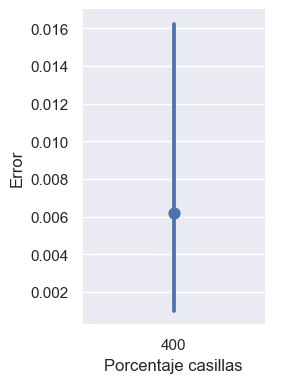

In [71]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [72]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c=df_metr_boot.drop(columns="Cobertura").merge(df_can_cob[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.508353,0.536531,0.028178,0.522527,0.515125,JOAQUIN_DIAZ_MENA,0.007402,400,0.968
1,2,0.501430,0.529601,0.028171,0.515628,0.515125,JOAQUIN_DIAZ_MENA,0.000503,400,0.968
2,3,0.496878,0.525677,0.028799,0.511482,0.515125,JOAQUIN_DIAZ_MENA,0.003643,400,0.968
3,4,0.503838,0.532788,0.028950,0.518947,0.515125,JOAQUIN_DIAZ_MENA,0.003821,400,0.968
4,5,0.502287,0.530310,0.028023,0.516344,0.515125,JOAQUIN_DIAZ_MENA,0.001219,400,0.968
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.020159,0.022797,0.002638,0.021446,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000021,400,0.950
4996,997,0.020669,0.024679,0.004010,0.022370,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000903,400,0.950
4997,998,0.019165,0.021449,0.002284,0.020221,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001246,400,0.950
4998,999,0.020148,0.022657,0.002508,0.021382,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000085,400,0.950


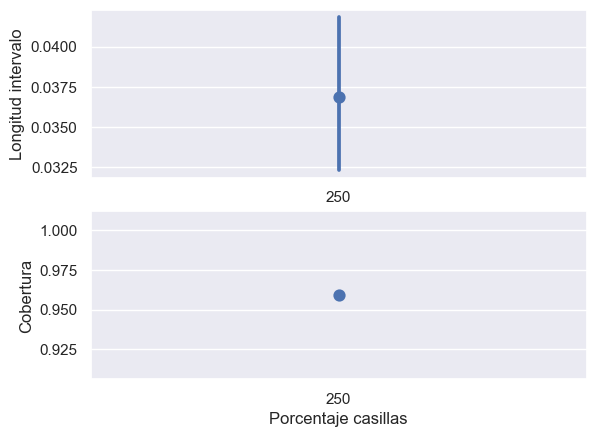

In [77]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c[df_metr_boot_c["Candidato"]==candidato_mas_largo], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c[df_metr_boot_c["Candidato"]==candidato_mas_largo].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


In [107]:
df_metr_boot_c[df_metr_boot_c["Candidato"]==candidato_mas_largo]

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
1000,1,0.396944,0.426947,0.030004,0.411326,0.421366,RENAN_BARRERA_CONCHA,0.010040,400,0.966
1001,2,0.406505,0.437410,0.030905,0.421465,0.421366,RENAN_BARRERA_CONCHA,0.000099,400,0.966
1002,3,0.410029,0.440724,0.030695,0.425007,0.421366,RENAN_BARRERA_CONCHA,0.003641,400,0.966
1003,4,0.403111,0.431896,0.028785,0.417150,0.421366,RENAN_BARRERA_CONCHA,0.004217,400,0.966
1004,5,0.408324,0.437473,0.029149,0.422687,0.421366,RENAN_BARRERA_CONCHA,0.001320,400,0.966
...,...,...,...,...,...,...,...,...,...,...
1995,996,0.412184,0.439390,0.027206,0.424865,0.421366,RENAN_BARRERA_CONCHA,0.003499,400,0.966
1996,997,0.403699,0.432418,0.028719,0.417710,0.421366,RENAN_BARRERA_CONCHA,0.003657,400,0.966
1997,998,0.413040,0.443455,0.030415,0.428194,0.421366,RENAN_BARRERA_CONCHA,0.006828,400,0.966
1998,999,0.414891,0.446152,0.031262,0.430258,0.421366,RENAN_BARRERA_CONCHA,0.008892,400,0.966


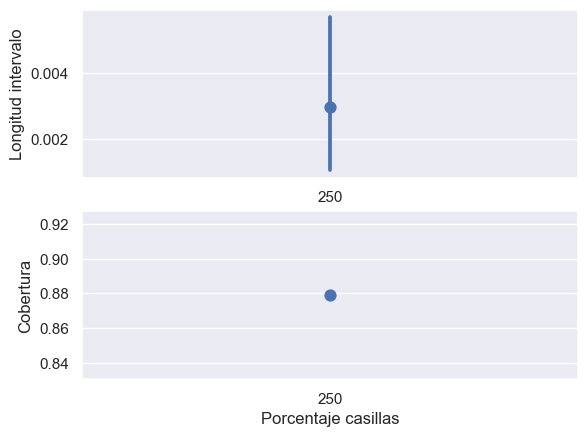

In [80]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c[df_metr_boot_c["Candidato"]==candidato_cober_men], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c[df_metr_boot_c["Candidato"]==candidato_cober_men].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

## Función de bootstrap estratificado

In [7]:
# Versión función
def boot_estratificado(df_act_yuc_i, num_boot: int=1000, n_sample=None, semilla=1):

    # Listas auxiliares para guardar los datos
    est_punt_list=[]

    inter_list=[]

    # Cuantas casillas hay por distrito en toda la base
    array_frec_est=np.array(df_act_yuc_i["DISTRITO"].value_counts().sort_index())

    for i in range(num_boot):

        # Número de poblaciones
        n_boot=1000

        # Hacemos el muestreo de tamaño n_sample de las casilas estratificado por distrito
        df_stra_sam=fab.muestreo_estratificado_mej(df_act_yuc_i, ["DISTRITO"], sample_size=n_sample, semilla=i+1+(num_boot*semilla))

        # Guardamos en un numpy array el dataframe de la muestra
        array_muest=np.array(df_stra_sam[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Los valores distintos de los distritos
        val_dist=df_stra_sam["DISTRITO"].sort_values().unique()

        # Separamos todos los distritos en distintos arrays
        valores_sep_est=[array_muest[array_muest[:,0]==val] for val in val_dist]

        # Los porcentajes de cada distrito en la muestra
        array_pesos_normalizados_dist=np.array(df_stra_sam["DISTRITO"].value_counts(normalize=True).sort_index())
        
        # Cuantas casillas hay por distrito en la muestra
        array_frec_est_mue=np.array(df_stra_sam["DISTRITO"].value_counts().sort_index())

        # Vector de pesos de la distribución Dirichlet
        vectores_dir=[fab.f(xi,n_boot, semilla=((semilla+1)*num_boot)+index+((i+1)*(100))) for index, xi in enumerate(array_frec_est_mue)]
        # Cuantas casillas hay por distrito en toda la base
        # array_frec_est=np.array(df_act_yuc_i["DISTRITO"].value_counts().sort_index())

        # Índices de la base por distritos
        #array_index_est=np.array(df_stra_sam.reset_index().groupby('DISTRITO')['index'].apply(list))

        #pesos_bootstrap=np.random.dirichlet(np.ones(df_stra_sam.shape[0], len(df_stra_sam["DISTRITO"].sort_values().unique())), n_boot)
        # Data frame con los resultados
        df_prop_list=[]

        for j in range(n_boot):

            # Lista de las casillas muestreadas por el bootstrap
            df_casillas_boot=[]

            # Semilla para las muestras de la Dirichlet
            rng = np.random.default_rng(i+1+(j*num_boot*(semilla+2)))

            # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
            for k in val_dist:

                # cas_sel_boot=np.random.choice(array_frec_est_mue[k-1], size = array_frec_est[k-1], p=vectores_dir[k-1][j])
                # df_casillas_boot.append(valores_sep_est[k-1][cas_sel_boot])

                # Calculamos una multinomial para completar la población (estratificada)
                # Utilizando los pesos bootstrap para cada casilla (estratificada)
                # Como resultado nos da las veces que se repitió cada casilla en la remuestra
                cas_sel_boot=rng.multinomial(n=array_frec_est[k-1], pvals=vectores_dir[k-1][j])

                # Guardamos todas las casillas (estratificadas) del bootstrap en un dataframe repitiendo el valor dependiendo
                # de su valor en la multinomial
                df_casillas_boot.append(valores_sep_est[k-1][np.repeat(np.arange(array_frec_est_mue[k-1]),cas_sel_boot)])

            # Juntamos todas las simulaciones
            # Solo utlizamos los datos remuestrados
            df_combined_m=np.vstack(df_casillas_boot)
            
            # df_combined_m=np.concatenate((array_muest, np.vstack(df_casillas_boot)))
            
            # Para poder agrupar en numpy
            # Ordenamos los datos por la primera columna (que es el distrito)
            df_combined_m=np.take(df_combined_m, df_combined_m[:, 0].argsort(kind='stable'), axis=0)

            # Vemos en que valor cambia el indice de (estrato)
            indices = np.nonzero(np.diff(df_combined_m[:, 0]))[0] + 1
            indices = np.concatenate(([0],indices))

            # Porcentaje de los candidatos por distritos
            array_por_est=np.add.reduceat(df_combined_m[:, 1:], indices)/np.array(np.add.reduceat(df_combined_m[:, 1:], indices).sum(1)).reshape(val_dist[-1],1)
            array_tot_agg=np.column_stack((df_combined_m[:,0][indices],array_por_est))

            # Obtenemos la estimacion puntual
            array_prop_i=(array_tot_agg[:,1:]*array_pesos_normalizados_dist.reshape(val_dist[-1],1)).sum(0)
            df_prop_list.append(array_prop_i)
        
        # Guardamos todo en un array con las estimaciones
        array_res=np.array(df_prop_list)

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))

        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)

    print(df_stra_sam.shape[0])
    
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)
    

    return array_inter_prob,array_est_punt


In [70]:
# Tamaño de la muestra
tama_muestra=350
inter_prob_est_e, est_punt_est_e=boot_estratificado(df_act_yuc_i, num_boot=1000, n_sample=tama_muestra, semilla=1)

350


In [8]:
%timeit boot_estratificado(df_act_yuc_i, num_boot=1000, n_sample=250)

250
250
250
250
250
250
250
250
4min 21s ± 1.76 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [71]:
# Guardamos las bases
df_metr_boot_est, df_error_max_est, df_can_cob_est= fab.metricas_bootstrap(prop_reales, inter_prob_est_e, est_punt_est_e, porcenta_tama=350)

In [63]:
df_can_cob_est

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,952,0.952,350
1,RENAN_BARRERA_CONCHA,955,0.955,350
2,VIDA_ARAVARI_GOMEZ_HERRERA,940,0.940,350
3,VOTOS_NULOS_CAND_NO_REGIS,959,0.959,350
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,904,0.904,350


In [139]:
# Candidato con intervalo más largo
df_inter_lar_est=df_metr_boot_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_est["Porcenta_tama"]=tama_muestra
candidato_mas_largo_est=df_inter_lar_est[df_inter_lar_est["Longitud_intervalo"]==df_inter_lar_est["Longitud_intervalo"].max()]["Candidato"].values[0]

In [140]:
# Candidato con menor cobertura
candidato_cober_men_est=df_can_cob_est[df_can_cob_est["Cobertura"]==df_can_cob_est["Cobertura"].min()]["Candidato"].values[0]

In [73]:
df_error_max_est.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.004959,350.0
std,288.819436,0.003052,0.0
min,1.000000,0.000384,350.0
2.5%,25.975000,0.000950,350.0
50%,500.500000,0.004244,350.0
97.5%,975.025000,0.012251,350.0
max,1000.000000,0.016795,350.0


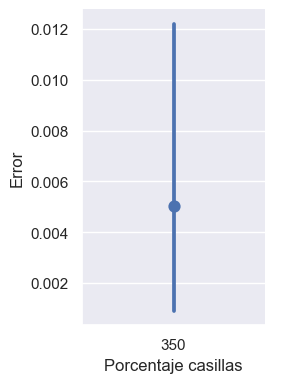

In [142]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_est, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [143]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_est=df_metr_boot_est.drop(columns="Cobertura").merge(df_can_cob_est[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_est

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.512896,0.532170,0.019274,0.522346,0.515125,JOAQUIN_DIAZ_MENA,0.007221,350,0.964
1,2,0.502973,0.522474,0.019500,0.512940,0.515125,JOAQUIN_DIAZ_MENA,0.002186,350,0.964
2,3,0.500594,0.520211,0.019617,0.510173,0.515125,JOAQUIN_DIAZ_MENA,0.004952,350,0.964
3,4,0.505117,0.525209,0.020093,0.515331,0.515125,JOAQUIN_DIAZ_MENA,0.000205,350,0.964
4,5,0.510083,0.530875,0.020792,0.520189,0.515125,JOAQUIN_DIAZ_MENA,0.005063,350,0.964
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.020434,0.022560,0.002126,0.021509,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000042,350,0.936
4996,997,0.020629,0.026980,0.006350,0.022945,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001478,350,0.936
4997,998,0.020467,0.023019,0.002552,0.021662,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000195,350,0.936
4998,999,0.020332,0.022591,0.002259,0.021406,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000061,350,0.936


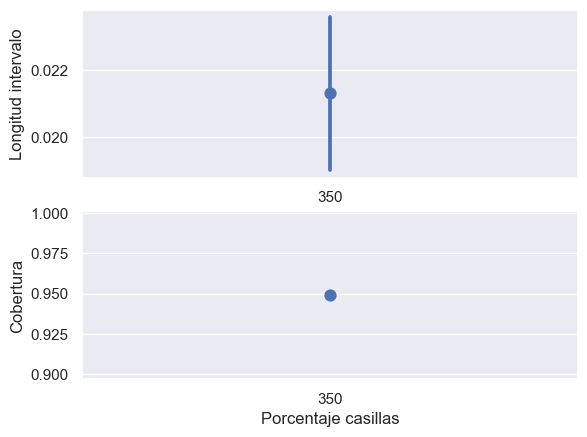

In [144]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_est[df_metr_boot_c_est["Candidato"]==candidato_mas_largo_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_est[df_metr_boot_c_est["Candidato"]==candidato_mas_largo_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


In [145]:
df_metr_boot_c_est[df_metr_boot_c_est["Candidato"]==candidato_mas_largo_est]

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
1000,1,0.404771,0.425540,0.020769,0.415321,0.421366,RENAN_BARRERA_CONCHA,0.006045,350,0.949
1001,2,0.414237,0.434353,0.020115,0.423982,0.421366,RENAN_BARRERA_CONCHA,0.002616,350,0.949
1002,3,0.417196,0.437318,0.020122,0.427360,0.421366,RENAN_BARRERA_CONCHA,0.005994,350,0.949
1003,4,0.410163,0.431917,0.021753,0.421132,0.421366,RENAN_BARRERA_CONCHA,0.000234,350,0.949
1004,5,0.404520,0.426592,0.022072,0.415793,0.421366,RENAN_BARRERA_CONCHA,0.005574,350,0.949
...,...,...,...,...,...,...,...,...,...,...
1995,996,0.405163,0.427888,0.022725,0.416938,0.421366,RENAN_BARRERA_CONCHA,0.004428,350,0.949
1996,997,0.408223,0.428013,0.019789,0.418127,0.421366,RENAN_BARRERA_CONCHA,0.003240,350,0.949
1997,998,0.416166,0.435482,0.019316,0.425738,0.421366,RENAN_BARRERA_CONCHA,0.004372,350,0.949
1998,999,0.406929,0.429662,0.022733,0.418035,0.421366,RENAN_BARRERA_CONCHA,0.003332,350,0.949


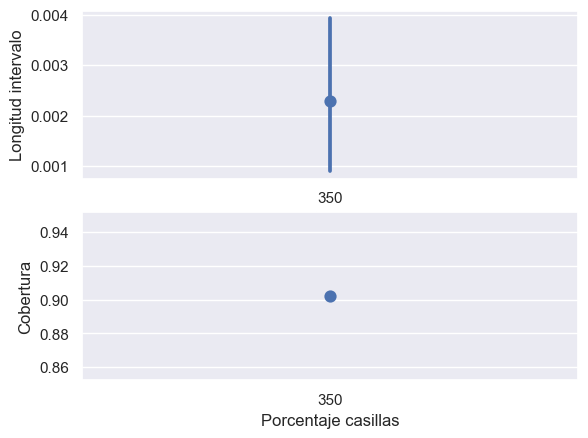

In [146]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_est[df_metr_boot_c_est["Candidato"]==candidato_cober_men_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_est[df_metr_boot_c_est["Candidato"]==candidato_cober_men_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

### Sin estratificar. Bootstraps con distintas muestras de casillas

In [85]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]

# Dataframe donde se guardará todo
df_boostraps_se=pd.DataFrame()

# Contador para el for
k=0

for mc in muestra_casillas:
    
        # Boostrap por votos (sin estratificar)
        inter_prob, est_punt=bootstrap_simple(df_act_yuc_i, num_boot=1000, n_sample=mc, semilla=k+1)
        # Calculamos las métricas
        df_metr_boot, df_error_max, df_can_cob= fab.metricas_bootstrap(prop_reales, inter_prob, est_punt, porcenta_tama=mc)

        # Los valores de las muestra y submuestras
        df_boostraps_se.loc[k,"Tamaño_muestra_casillas"]= mc

        # Las métricas para el error máximo
        df_boostraps_se.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_m_l_c=df_metr_boot.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_se.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l_c
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_se.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob[df_can_cob["Candidato"]==candidato_int_m_l_c]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_se.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot[df_metr_boot["Candidato"]==candidato_int_m_l_c]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_men=df_can_cob[df_can_cob["Cobertura"]==df_can_cob["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_se.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men
        # Cobertura del candidato con menor cobertura
        df_boostraps_se.loc[k, ["Cobertura_m_candidato"]]=df_can_cob[df_can_cob["Candidato"]==candidato_cober_men]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_se.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot[df_metr_boot["Candidato"]==candidato_cober_men]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        
        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_se.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mc)

100
Muestra casillas: 100
150
Muestra casillas: 150
200
Muestra casillas: 200
250
Muestra casillas: 250
300
Muestra casillas: 300
350
Muestra casillas: 350
400
Muestra casillas: 400


In [86]:
# Agregamos una columna para identificar que es sin estratificar
df_boostraps_se["Estratificación"] = "Sin estratificar (casillas)"
df_boostraps_se

,Tamaño_muestra_casillas,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE,Estratificación
0,100.0,0.002091,0.010938,0.032888,JOAQUIN_DIAZ_MENA,0.953,0.043243,0.054123,0.064861,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.767,0.001334,0.003784,0.011767,0.953,0.949,0.910,0.935,0.767,Sin estratificar (casillas)
1,150.0,0.001695,0.009373,0.026799,JOAQUIN_DIAZ_MENA,0.947,0.037632,0.044825,0.052716,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.765,0.001162,0.003264,0.008237,0.947,0.944,0.921,0.929,0.765,Sin estratificar (casillas)
2,200.0,0.001543,0.007747,0.022424,JOAQUIN_DIAZ_MENA,0.963,0.034233,0.039154,0.045507,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.841,0.001110,0.003103,0.006707,0.963,0.962,0.947,0.935,0.841,Sin estratificar (casillas)
3,250.0,0.001480,0.006607,0.020565,JOAQUIN_DIAZ_MENA,0.963,0.031191,0.035606,0.040110,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.880,0.001068,0.002899,0.006002,0.963,0.959,0.944,0.938,0.880,Sin estratificar (casillas)
4,300.0,0.001133,0.006256,0.018233,JOAQUIN_DIAZ_MENA,0.966,0.029029,0.032729,0.036931,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.885,0.000992,0.002691,0.005223,0.966,0.968,0.956,0.942,0.885,Sin estratificar (casillas)
5,350.0,0.001005,0.005511,0.016222,JOAQUIN_DIAZ_MENA,0.969,0.027294,0.030655,0.034343,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.902,0.001055,0.002519,0.004701,0.969,0.975,0.958,0.947,0.902,Sin estratificar (casillas)
6,400.0,0.000956,0.005041,0.014980,JOAQUIN_DIAZ_MENA,0.975,0.025912,0.028907,0.032051,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.929,0.001027,0.002452,0.004369,0.975,0.974,0.960,0.957,0.929,Sin estratificar (casillas)


In [90]:
# Leemos el csv con los datos
df_boostraps_se.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_sin_est_f_1.csv")

In [31]:
# Guardamos un csv
#df_boostraps_se.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Boostrap por casillas/Distintas_muestras_submuestras_bootstrap_casillas_sin_est_1.csv")

### Estratificado. Bootstraps con distintas muestras de casillas

In [92]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]

# Dataframe donde se guardará todo
df_boostraps_e=pd.DataFrame()

# Contador para el for
k=0

# Hacemos los for sobre el tamaño de las muestras y submuestras
for mc in muestra_casillas:
    # Para medir cuanto tiempo se tarda en correr
    loop_time = time.time()
    # Boostrap por votos (estratificado)
    inter_prob_v_est, est_punt_v_est=boot_estratificado(df_act_yuc_i, num_boot=1000, n_sample=mc, semilla=k+1)

    # Calculamos las métricas
    df_metr_boot_est, df_error_max_est, df_can_cob_est= fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=mc)

    # Los valores de las muestra y submuestras
    df_boostraps_e.loc[k,"Tamaño_muestra_casillas"]=mc

    # Las métricas para el error máximo
    df_boostraps_e.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_est["Error_max"].quantile([0.025,0.5,0.975]).to_list()

    # Calculamos el candidato que tenga intervalos más largos (en promedio)
    candidato_int_m_l_c_est=df_metr_boot_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
    # Candidato con el intervalos más grandes
    df_boostraps_e.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l_c_est
    # Cobertura del candidato con el intervalos más grandes
    df_boostraps_e.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_est[df_can_cob_est["Candidato"]==candidato_int_m_l_c_est]["Cobertura"].values[0]
    # Las métricas del candidato con los intervalos más grandes
    df_boostraps_e.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_est[df_metr_boot_est["Candidato"]==candidato_int_m_l_c_est]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

    # Calculamos el candidato con la menor cobertura
    # Candidato con menor cobertura
    candidato_cober_men_est=df_can_cob_est[df_can_cob_est["Cobertura"]==df_can_cob_est["Cobertura"].min()]["Candidato"].values[0]

    # Candidato con el intervalos más grandes
    df_boostraps_e.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men_est
    # Cobertura del candidato con menor cobertura
    df_boostraps_e.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_est[df_can_cob_est["Candidato"]==candidato_cober_men_est]["Cobertura"].values[0]
    # Las métricas del candidato con la menor cobertura
    df_boostraps_e.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_est[df_metr_boot_est["Candidato"]==candidato_cober_men_est]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

    
    # Coberturas de los candidatos en el bootstrap 
    df_boostraps_e.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_est.sort_values(by="Candidato")["Cobertura"].to_list()

    k=k+1
    
    print("Muestra casillas:", mc)
    print('Tiempo que tarda correr una iteración del for {}'.format((time.time() - loop_time)))  

# Lo guardamos en otra base copia por si sin querer pongo a correr el código
df_boostraps_e_f=df_boostraps_e.copy()
df_boostraps_e_f["Estratificación"] = "Estratificación por distritos (casillas)"

100
Muestra casillas: 100
Tiempo que tarda correr una iteración del for 244.52920293807983
150
Muestra casillas: 150
Tiempo que tarda correr una iteración del for 250.3801131248474
200
Muestra casillas: 200
Tiempo que tarda correr una iteración del for 255.0781900882721
250
Muestra casillas: 250
Tiempo que tarda correr una iteración del for 259.8539559841156
300
Muestra casillas: 300
Tiempo que tarda correr una iteración del for 263.66188311576843
350
Muestra casillas: 350
Tiempo que tarda correr una iteración del for 267.7879638671875
400
Muestra casillas: 400
Tiempo que tarda correr una iteración del for 278.0620708465576


In [93]:
df_boostraps_e_f

,Tamaño_muestra_casillas,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE,Estratificación
0,100.0,0.001537,0.008362,0.024037,JOAQUIN_DIAZ_MENA,0.879,0.025476,0.031068,0.037963,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.701,0.001050,0.002811,0.009113,0.879,0.875,0.822,0.869,0.701,Estratificación por distritos (casillas)
1,150.0,0.001409,0.007068,0.020893,JOAQUIN_DIAZ_MENA,0.896,0.023046,0.027216,0.031845,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.753,0.001005,0.002634,0.007074,0.896,0.893,0.887,0.914,0.753,Estratificación por distritos (casillas)
2,200.0,0.001110,0.005724,0.015900,JOAQUIN_DIAZ_MENA,0.929,0.021287,0.024775,0.028457,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.812,0.000955,0.002460,0.005670,0.929,0.927,0.904,0.922,0.812,Estratificación por distritos (casillas)
3,250.0,0.001144,0.005427,0.015573,JOAQUIN_DIAZ_MENA,0.930,0.020072,0.022865,0.025758,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.862,0.000940,0.002416,0.005015,0.930,0.930,0.906,0.925,0.862,Estratificación por distritos (casillas)
4,300.0,0.000982,0.004724,0.012998,JOAQUIN_DIAZ_MENA,0.958,0.019127,0.021397,0.023866,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.890,0.000936,0.002347,0.004584,0.958,0.952,0.912,0.936,0.890,Estratificación por distritos (casillas)
5,350.0,0.000967,0.004612,0.012292,JOAQUIN_DIAZ_MENA,0.960,0.018085,0.020251,0.022454,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.901,0.000903,0.002253,0.004063,0.960,0.948,0.919,0.963,0.901,Estratificación por distritos (casillas)
6,400.0,0.000962,0.004097,0.012193,JOAQUIN_DIAZ_MENA,0.957,0.017255,0.019203,0.021179,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.900,0.000904,0.002146,0.003637,0.957,0.942,0.931,0.942,0.900,Estratificación por distritos (casillas)


In [94]:
# Leemos los datos
df_boostraps_e_f.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_estratificado_f_1.csv")

In [36]:
# Juntamos las bases
df_boostraps_c=pd.concat([df_boostraps_se, df_boostraps_e_f]).reset_index(drop=True)
df_boostraps_c

,Tamaño_muestra_casillas,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE,Estratificación
0,100.0,0.002082,0.011726,0.032818,JOAQUIN_DIAZ_MENA,0.948,0.043906,0.054279,0.066212,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.730,0.001281,0.003450,0.011382,0.948,0.941,0.917,0.928,0.730,Sin estratificar (casillas)
1,150.0,0.001481,0.009102,0.027687,JOAQUIN_DIAZ_MENA,0.945,0.037443,0.044915,0.052655,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.809,0.001186,0.003373,0.008262,0.945,0.950,0.936,0.941,0.809,Sin estratificar (casillas)
2,200.0,0.001470,0.007852,0.022880,JOAQUIN_DIAZ_MENA,0.955,0.034174,0.039497,0.044929,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.826,0.001083,0.002989,0.006531,0.955,0.961,0.946,0.941,0.826,Sin estratificar (casillas)
3,250.0,0.001444,0.006472,0.020072,JOAQUIN_DIAZ_MENA,0.963,0.031203,0.035486,0.040258,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.864,0.001044,0.002901,0.005749,0.963,0.956,0.946,0.941,0.864,Sin estratificar (casillas)
4,300.0,0.001181,0.005938,0.018555,JOAQUIN_DIAZ_MENA,0.963,0.029041,0.032597,0.036722,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.880,0.000993,0.002691,0.005168,0.963,0.966,0.952,0.937,0.880,Sin estratificar (casillas)
5,350.0,0.001161,0.005860,0.016537,JOAQUIN_DIAZ_MENA,0.964,0.027405,0.030672,0.033889,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.909,0.001028,0.002552,0.004640,0.964,0.971,0.943,0.954,0.909,Sin estratificar (casillas)
6,400.0,0.001071,0.005357,0.016599,JOAQUIN_DIAZ_MENA,0.964,0.025817,0.028835,0.031960,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.929,0.001045,0.002429,0.004210,0.964,0.962,0.960,0.951,0.929,Sin estratificar (casillas)
7,100.0,0.001909,0.008420,0.024146,JOAQUIN_DIAZ_MENA,0.872,0.025369,0.030919,0.036931,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.680,0.001046,0.002652,0.009110,0.872,0.868,0.847,0.870,0.680,Estratificación por distritos (casillas)
8,150.0,0.001521,0.007042,0.019725,JOAQUIN_DIAZ_MENA,0.919,0.023360,0.027289,0.031747,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.771,0.000997,0.002603,0.007019,0.919,0.900,0.870,0.907,0.771,Estratificación por distritos (casillas)
9,200.0,0.001215,0.005826,0.016717,JOAQUIN_DIAZ_MENA,0.931,0.021536,0.024856,0.028727,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.804,0.000941,0.002465,0.005696,0.931,0.919,0.897,0.933,0.804,Estratificación por distritos (casillas)


<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
/var/folders/jr/f7xjgzh56h75snyd84nvhbdc0000gn/T/ipykernel_5634/979917238.py:12: SyntaxWarning: invalid escape sequence '\e'
  per.figure.suptitle('Errores máximos ($\epsilon$) comparados (bootstrap casillas)');


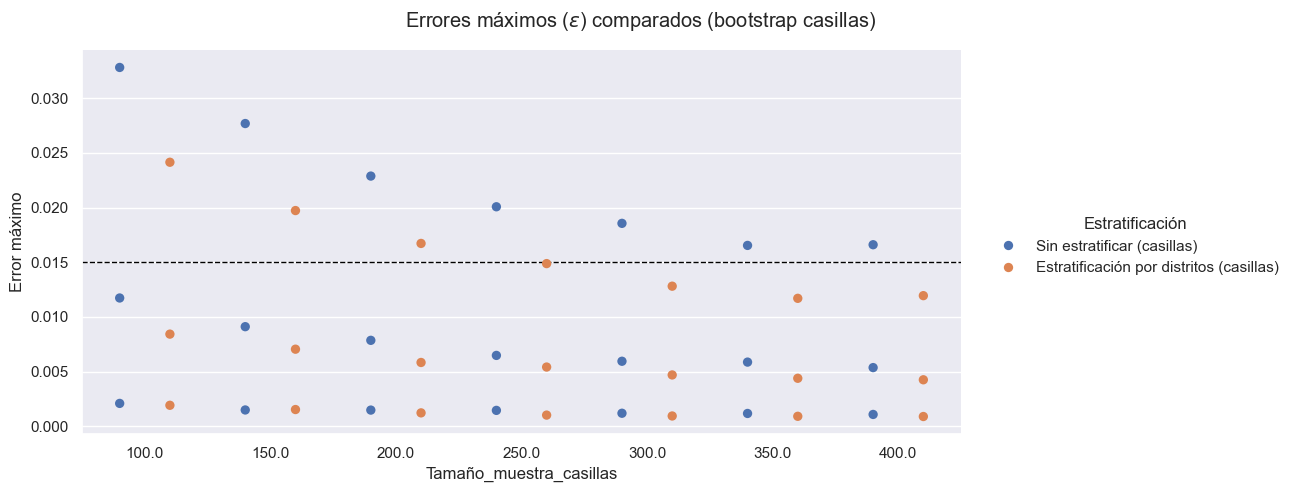

In [64]:
# Para hacer la gráfica del error con los distintos tamaños de la submuestra de votos
df_grafica_error_aux_c=pd.melt(df_boostraps_c[["Tamaño_muestra_casillas", "Estratificación", "Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per=sns.catplot(data=df_grafica_error_aux_c, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45).set_titles("A");

per.set(xlabel='Tamaño_muestra_casillas', ylabel='Error máximo')

per.refline(y=0.015, linewidth=1, color='black', ls='--');
per.figure.subplots_adjust(top=0.9);
per.figure.suptitle('Errores máximos ($\epsilon$) comparados (bootstrap casillas)');

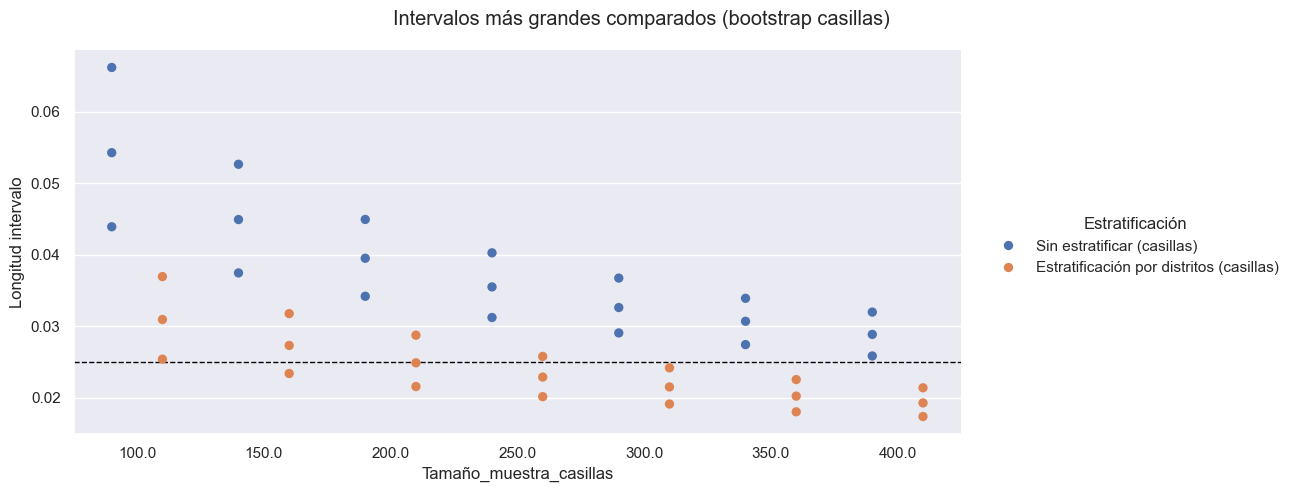

In [65]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_im_aux_c=pd.melt(df_boostraps_c[["Tamaño_muestra_casillas", "Estratificación", "Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_i=sns.catplot(data=df_grafica_int_im_aux_c, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45);

per_i.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_i.refline(y=0.025, linewidth=1, color='black', ls='--');
per_i.figure.subplots_adjust(top=0.9)
per_i.figure.suptitle('Intervalos más grandes comparados (bootstrap casillas)');

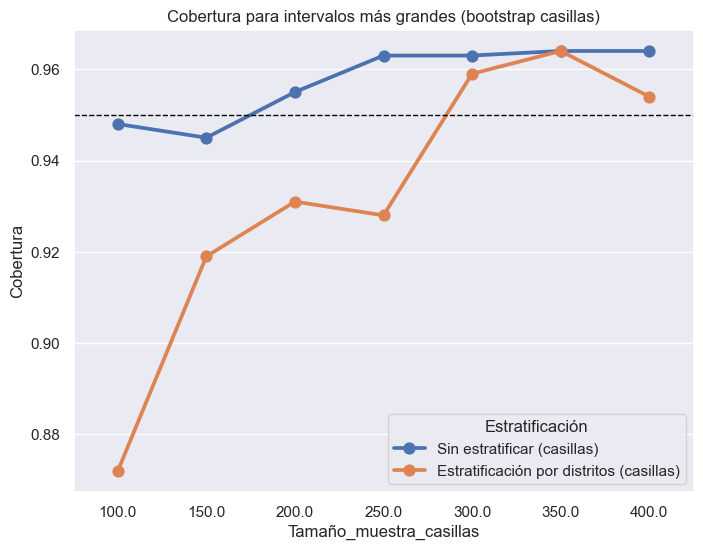

In [39]:
fig, ax = plt.subplots(figsize=(8,6))

per_c=sns.pointplot(ax=ax,
    data=df_boostraps_c, x="Tamaño_muestra_casillas", y="Intervalo_M_grande_candidato_cob", hue="Estratificación"
).set_title("Cobertura para intervalos más grandes (bootstrap casillas)");
ax.set(ylabel='Cobertura')
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

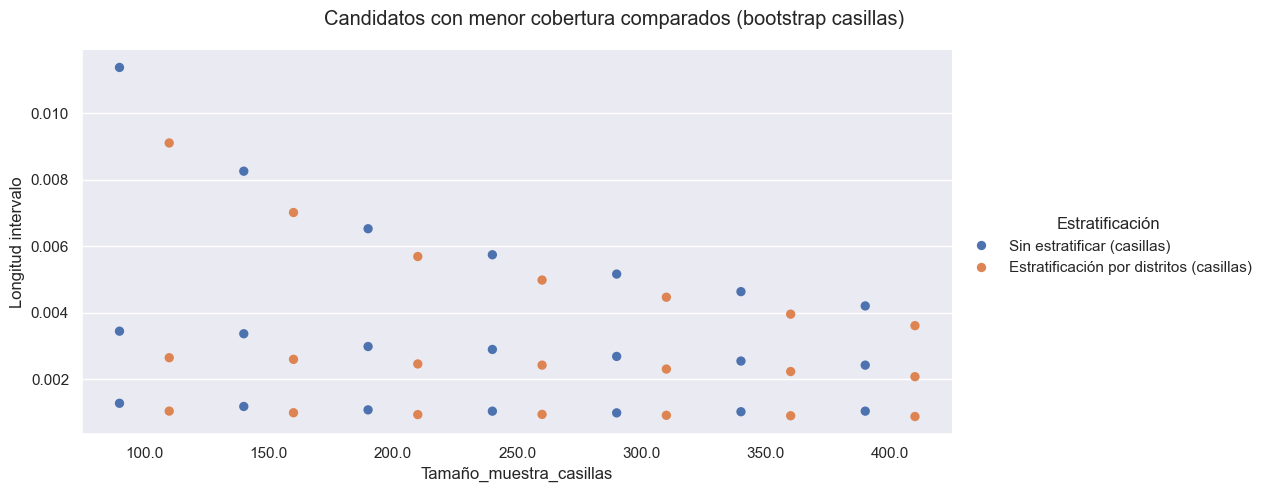

In [40]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_mc_aux_c=pd.melt(df_boostraps_c[["Tamaño_muestra_casillas", "Estratificación", "Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Estratificación"], value_vars=["Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_mc=sns.catplot(data=df_grafica_int_mc_aux_c, x="Tamaño_muestra_casillas", y="value", hue="Estratificación", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45);

per_mc.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_mc.figure.subplots_adjust(top=0.9)
per_mc.figure.suptitle('Candidatos con menor cobertura comparados (bootstrap casillas)');

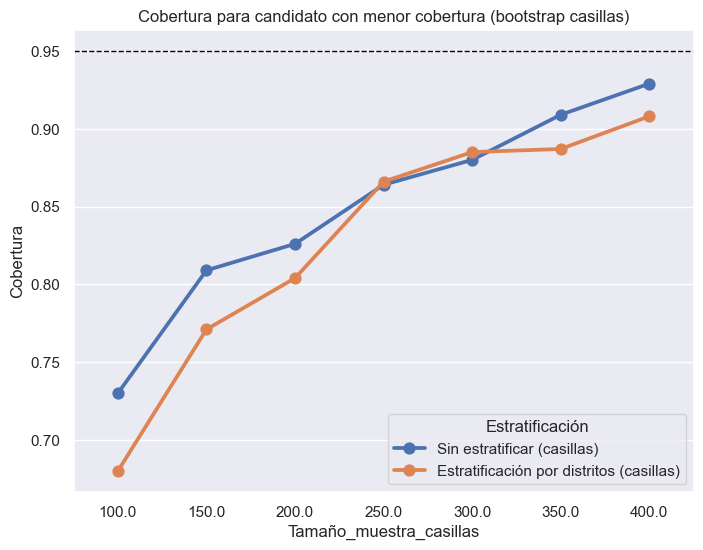

In [41]:
fig, ax = plt.subplots(figsize=(8,6))

sns.pointplot(ax=ax, data=df_boostraps_c, x="Tamaño_muestra_casillas", y="Cobertura_m_candidato", hue="Estratificación").set_title("Cobertura para candidato con menor cobertura (bootstrap casillas)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');